[INFO] Đang tải Database Vector (Đã phân tách chuẩn)...
[INFO] Số mẫu Train: 4878 | Số mẫu Test: 182

[INFO] Đang khởi tạo kiến trúc MLP Cơ bản...

[INFO] BẮT ĐẦU TRAINING...
Train on 3902 samples, validate on 976 samples
Epoch 1/10
3902/3902 [==============================] - 1s 296us/step - loss: 1.3189 - acc: 0.8137 - val_loss: 0.5180 - val_acc: 0.9846
Epoch 2/10
3902/3902 [==============================] - 0s 118us/step - loss: 0.3931 - acc: 0.9649 - val_loss: 0.1524 - val_acc: 0.9918
Epoch 3/10
3902/3902 [==============================] - 0s 104us/step - loss: 0.1990 - acc: 0.9785 - val_loss: 0.0781 - val_acc: 0.9928
Epoch 4/10
3902/3902 [==============================] - 0s 96us/step - loss: 0.1341 - acc: 0.9844 - val_loss: 0.0510 - val_acc: 0.9959
Epoch 5/10
3902/3902 [==============================] - 0s 97us/step - loss: 0.0999 - acc: 0.9892 - val_loss: 0.0368 - val_acc: 0.9959
Epoch 6/10
3902/3902 [==============================] - 0s 96us/step - loss: 0.0746 - acc: 0.9910 - 

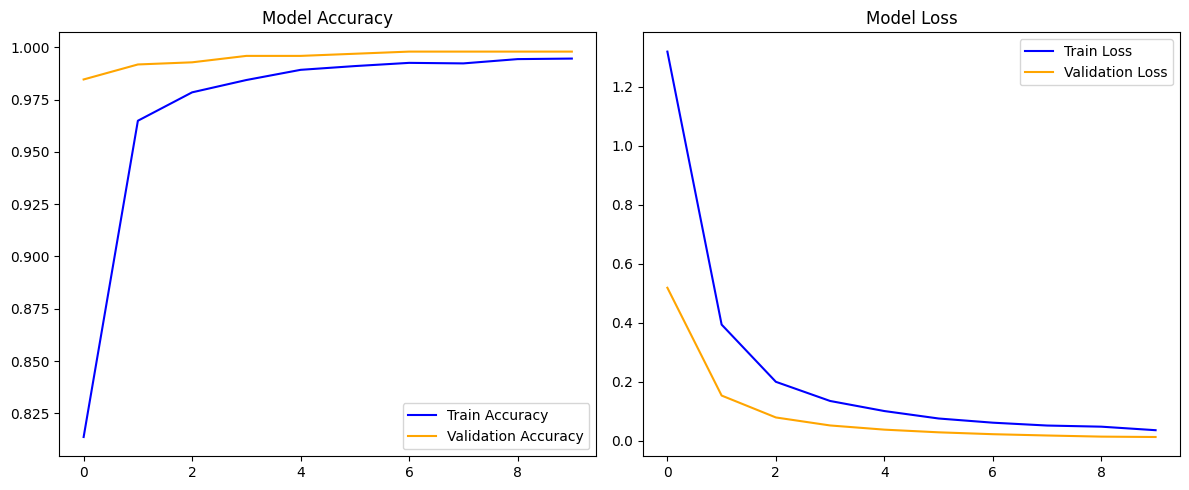


--- BÁO CÁO PHÂN LOẠI TRÊN UNSEEN DATA ---
                 precision    recall  f1-score   support

 cs-anh-tu-atus       1.00      1.00      1.00        23
      cs-cam-ly       1.00      1.00      1.00        13
      cs-my-tam       0.97      1.00      0.98        29
   dv-lam-vy-da       1.00      0.94      0.97        18
  dv-quang-tuan       1.00      1.00      1.00        20
   dv-thu-trang       1.00      1.00      1.00        20
   dv-tien-luat       1.00      1.00      1.00        24
dv-truong-giang       1.00      1.00      1.00        20
  str-cris-phan       1.00      1.00      1.00        15

       accuracy                           0.99       182
      macro avg       1.00      0.99      0.99       182
   weighted avg       0.99      0.99      0.99       182



<Figure size 2000x2000 with 0 Axes>

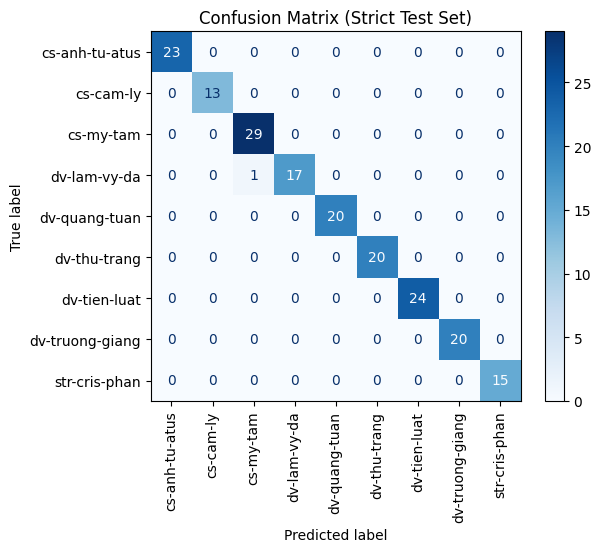

In [31]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical
import keras.regularizers as regularizers

INPUT_DB = 'face_vectors_db_strict.pkl'
OUTPUT_MODEL = 'mlp_face_classifier.h5'
OUTPUT_ENCODER = 'label_encoder.pkl'
OUTPUT_CENTROIDS = 'centroids.pkl' 

def calculate_centroids(X_train, y_train, num_classes):
    """Tính toán vector trung bình cho mỗi class"""
    centroids = {}
    for cls in range(num_classes):
        class_vectors = X_train[y_train == cls]
        centroids[cls] = np.mean(class_vectors, axis=0)
    return centroids

def main():
    print("[INFO] Đang tải Database Vector (Đã phân tách chuẩn)...")
    try:
        with open(INPUT_DB, 'rb') as f:
            X_train_raw, y_train_raw, X_test_raw, y_test_raw = pickle.load(f)
    except FileNotFoundError:
        print(f"[LỖI] Không tìm thấy {INPUT_DB}")
        return

    X_train, X_test = np.array(X_train_raw), np.array(X_test_raw)
    
    # 1. MÃ HÓA NHÃN CẨN THẬN
    le = LabelEncoder()
    # Chỉ "học" từ điển trên tập Train, sau đó áp dụng để dịch cho cả 2 tập
    y_train_encoded = le.fit_transform(y_train_raw)
    y_test_encoded = le.transform(y_test_raw)
    
    num_classes = len(le.classes_)
    y_train_categorical = to_categorical(y_train_encoded, num_classes=num_classes)
    y_test_categorical = to_categorical(y_test_encoded, num_classes=num_classes)

    print(f"[INFO] Số mẫu Train: {len(X_train)} | Số mẫu Test: {len(X_test)}")

    # THỰC NGHIỆM 1: Kiến trúc MLP Cơ bản (Baseline)
    print("\n[INFO] Đang khởi tạo kiến trúc MLP Cơ bản...")
    model = Sequential([
        Dense(64, activation='relu', input_shape=(2048,), name='Dense_1'),
        Dropout(0.5, name='Dropout_1'), 
        
        # Dense(128, activation='relu', name='Dense_2', kernel_regularizer=regularizers.l2(0.05)),
        # Dropout(0.3, name='Dropout_2'),
        
        Dense(num_classes, activation='softmax', name='Output_Layer')
    ])

    model.compile(optimizer=Adam(lr=0.0005), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
                  
    # Khi model.fit, bạn dùng epochs=40

    # 3. TRAINING
    print("\n[INFO] BẮT ĐẦU TRAINING...")
    history = model.fit(
        X_train, y_train_categorical,
        epochs=10, 
        batch_size=16,
        validation_split=0.2,
        verbose=1
    )

    model.save(OUTPUT_MODEL)
    with open(OUTPUT_ENCODER, 'wb') as f:
        pickle.dump(le, f)

    print("\n[INFO] Đang tính toán và lưu Vector trung tâm (Centroids)...")
    centroids_dict = calculate_centroids(X_train, y_train_encoded, num_classes)
    with open(OUTPUT_CENTROIDS, 'wb') as f:
        pickle.dump(centroids_dict, f)
    print(f"[INFO] Đã lưu {OUTPUT_CENTROIDS} thành công!") 

    # 4. XUẤT BÁO CÁO THỰC NGHIỆM
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['acc'], label='Train Accuracy', color='blue')
    plt.plot(history.history['val_acc'], label='Validation Accuracy', color='orange')
    plt.title('Model Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Model Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Đánh giá trên tập Test CỨNG (Unseen Data)
    y_pred_probs = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    
    print("\n--- BÁO CÁO PHÂN LOẠI TRÊN UNSEEN DATA ---")
    target_names = [str(cls) for cls in le.classes_]
    print(classification_report(y_test_encoded, y_pred_classes, target_names=target_names))

    cm = confusion_matrix(y_test_encoded, y_pred_classes)
    plt.figure(figsize=(20, 20))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap='Blues')
    plt.xticks(rotation=90)
    plt.title("Confusion Matrix (Strict Test Set)")
    plt.show()

if __name__ == '__main__':
    main()

# Phần dưới không cần quan tâm

[INFO] Đang tải Database Vector (Đã phân tách chuẩn)...
[INFO] Số mẫu Train: 6622 | Số mẫu Test: 419

[INFO] Đang khởi tạo kiến trúc MLP Cơ bản...

[INFO] BẮT ĐẦU TRAINING...
Train on 6622 samples, validate on 419 samples
Epoch 1/15
6622/6622 [==============================] - 3s 427us/step - loss: 2.7460 - acc: 0.6108 - val_loss: 0.8992 - val_acc: 0.9594
Epoch 2/15
6622/6622 [==============================] - 2s 367us/step - loss: 0.7783 - acc: 0.9308 - val_loss: 0.5486 - val_acc: 0.9761
Epoch 3/15
6622/6622 [==============================] - 2s 350us/step - loss: 0.5140 - acc: 0.9633 - val_loss: 0.4467 - val_acc: 0.9642
Epoch 4/15
6622/6622 [==============================] - 2s 340us/step - loss: 0.4028 - acc: 0.9725 - val_loss: 0.3643 - val_acc: 0.9833
Epoch 5/15
6622/6622 [==============================] - 2s 332us/step - loss: 0.3303 - acc: 0.9781 - val_loss: 0.3353 - val_acc: 0.9785
Epoch 6/15
6622/6622 [==============================] - 2s 326us/step - loss: 0.2879 - acc: 0.9841

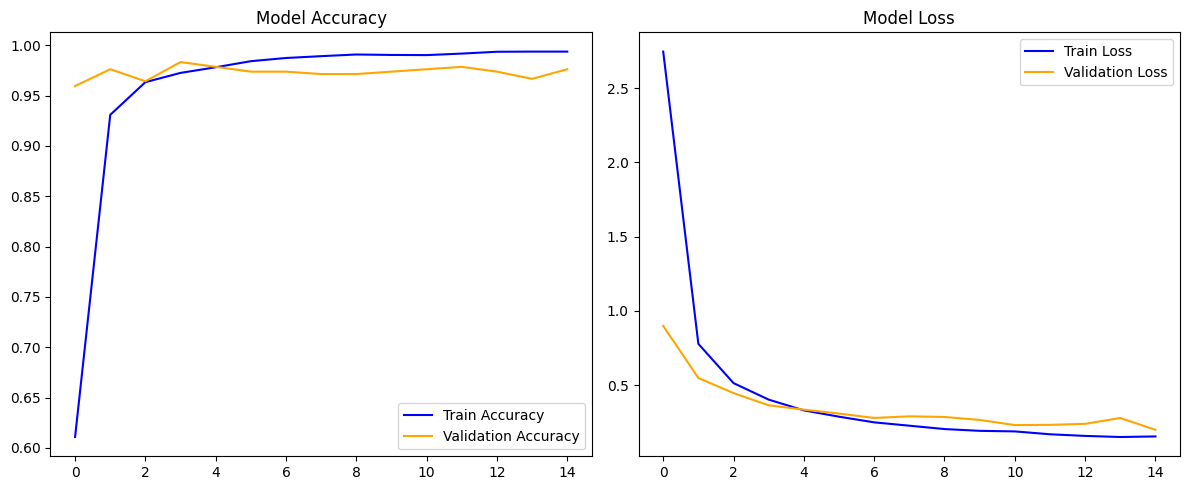


--- BÁO CÁO PHÂN LOẠI TRÊN UNSEEN DATA ---
                          precision    recall  f1-score   support

            casiBangKieu       0.94      1.00      0.97        17
          casiBichPhuong       1.00      1.00      1.00        19
               casiCamLy       0.95      1.00      0.97        19
         casiDamVinhHung       1.00      1.00      1.00        19
           casiDanTruong       1.00      1.00      1.00        18
                casiErik       1.00      1.00      1.00        19
           casiHaAnhTuan       0.95      1.00      0.97        18
             casiHoaiLam       1.00      1.00      1.00        18
       casiHoangThuyLinh       1.00      1.00      1.00        20
               casiKarik       1.00      0.88      0.94        17
          casiNgoKienHuy       1.00      1.00      1.00        19
       casiNooPhuocThinh       1.00      0.94      0.97        17
             casiQuangLe       0.95      1.00      0.97        19
          casiSTSonThach       

<Figure size 2000x2000 with 0 Axes>

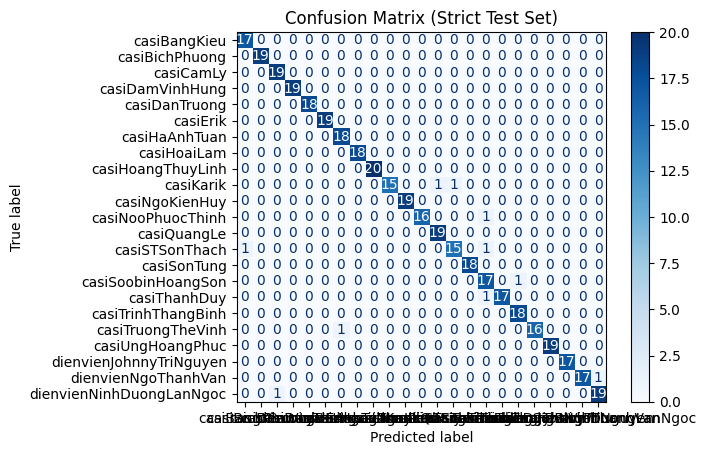

In [ ]:
import keras.regularizers as regularizers

INPUT_DB = 'face_vectors_db_strict.pkl'
OUTPUT_MODEL = 'mlp_face_classifier.h5'
OUTPUT_ENCODER = 'label_encoder.pkl'
OUTPUT_CENTROIDS = 'centroids.pkl' 

def calculate_centroids(X_train, y_train, num_classes):
    """Tính toán vector trung bình cho mỗi class"""
    centroids = {}
    for cls in range(num_classes):
        class_vectors = X_train[y_train == cls]
        centroids[cls] = np.mean(class_vectors, axis=0)
    return centroids

def main():
    print("[INFO] Đang tải Database Vector (Đã phân tách chuẩn)...")
    try:
        with open(INPUT_DB, 'rb') as f:
            X_train_raw, y_train_raw, X_test_raw, y_test_raw = pickle.load(f)
    except FileNotFoundError:
        print(f"[LỖI] Không tìm thấy {INPUT_DB}")
        return

    X_train, X_test = np.array(X_train_raw), np.array(X_test_raw)
    
    # 1. MÃ HÓA NHÃN CẨN THẬN
    le = LabelEncoder()
    # Chỉ "học" từ điển trên tập Train, sau đó áp dụng để dịch cho cả 2 tập
    y_train_encoded = le.fit_transform(y_train_raw)
    y_test_encoded = le.transform(y_test_raw)
    
    num_classes = len(le.classes_)
    y_train_categorical = to_categorical(y_train_encoded, num_classes=num_classes)
    y_test_categorical = to_categorical(y_test_encoded, num_classes=num_classes)

    print(f"[INFO] Số mẫu Train: {len(X_train)} | Số mẫu Test: {len(X_test)}")

    # THỰC NGHIỆM 1: Kiến trúc MLP Cơ bản (Baseline)
    print("\n[INFO] Đang khởi tạo kiến trúc MLP Cơ bản...")
    model = Sequential([
        Dense(256, activation='relu', input_shape=(2048,), name='Dense_1'),
        Dropout(0.5, name='Dropout_1'), 
        
        Dense(128, activation='relu', name='Dense_2', kernel_regularizer=regularizers.l2(0.05)),
        Dropout(0.3, name='Dropout_2'),
        
        Dense(num_classes, activation='softmax', name='Output_Layer')
    ])

    model.compile(optimizer=Adam(lr=0.001), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
                  
    # Khi model.fit, bạn dùng epochs=10

    # 3. TRAINING
    print("\n[INFO] BẮT ĐẦU TRAINING...")
    history = model.fit(
        X_train, y_train_categorical,
        epochs=15, 
        batch_size=16,
        validation_data=(X_test, y_test_categorical),
        verbose=1
    )

    model.save(OUTPUT_MODEL)
    with open(OUTPUT_ENCODER, 'wb') as f:
        pickle.dump(le, f)

    print("\n[INFO] Đang tính toán và lưu Vector trung tâm (Centroids)...")
    centroids_dict = calculate_centroids(X_train, y_train_encoded, num_classes)
    with open(OUTPUT_CENTROIDS, 'wb') as f:
        pickle.dump(centroids_dict, f)
    print(f"[INFO] Đã lưu {OUTPUT_CENTROIDS} thành công!") 

    # 4. XUẤT BÁO CÁO THỰC NGHIỆM
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['acc'], label='Train Accuracy', color='blue')
    plt.plot(history.history['val_acc'], label='Validation Accuracy', color='orange')
    plt.title('Model Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Model Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Đánh giá trên tập Test CỨNG (Unseen Data)
    y_pred_probs = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    
    print("\n--- BÁO CÁO PHÂN LOẠI TRÊN UNSEEN DATA ---")
    target_names = [str(cls) for cls in le.classes_]
    print(classification_report(y_test_encoded, y_pred_classes, target_names=target_names))

    cm = confusion_matrix(y_test_encoded, y_pred_classes)
    plt.figure(figsize=(20, 20))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix (Strict Test Set)")
    plt.show()

if __name__ == '__main__':
    main()

In [23]:
import os

# Thư mục cha chứa các folder người
output_dir = "output_cropped_faces"

# Lấy tất cả folder con
folders = [f for f in os.listdir(output_dir) if os.path.isdir(os.path.join(output_dir, f))]

# Đếm số file trong từng folder
for folder in folders:
    folder_path = os.path.join(output_dir, folder)
    num_images = len([f for f in os.listdir(folder_path)
                      if os.path.isfile(os.path.join(folder_path, f)) 
                      and f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    
    print(folder, ":", num_images, "ảnh")

casiBangKieu : 42 ảnh
casiBichPhuong : 46 ảnh
casiCamLy : 46 ảnh
casiDamVinhHung : 46 ảnh
casiDanTruong : 44 ảnh
casiErik : 46 ảnh
casiHaAnhTuan : 45 ảnh
casiHoaiLam : 45 ảnh
casiHoangThuyLinh : 48 ảnh
casiKarik : 42 ảnh
casiNgoKienHuy : 46 ảnh
casiNooPhuocThinh : 41 ảnh
casiQuangLe : 47 ảnh
casiSonTung : 44 ảnh
casiSoobinHoangSon : 43 ảnh
casiSTSonThach : 41 ảnh
casiThanhDuy : 44 ảnh
casiTrinhThangBinh : 43 ảnh
casiTruongTheVinh : 41 ảnh
casiUngHoangPhuc : 47 ảnh
dienvienJohnnyTriNguyen : 41 ảnh
dienvienNgoThanhVan : 45 ảnh
dienvienNinhDuongLanNgoc : 48 ảnh
